# Text Generation using Vanilla RNN, LSTM and GRU

This notebook demonstrates how to implement text generation using various recurrent neural network (RNN) architectures: Vanilla RNN, Long Short-Term Memory (LSTM), and Gated Recurrent Unit (GRU). We will train these models on a small corpus of text to predict the next word in a sequence.

## Final Training Accuracy

## 1. Setup and Imports

In [22]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## 2. Dataset

In [23]:
text = """
artificial intelligence is changing the world
deep learning is a powerful branch of artificial intelligence
recurrent neural networks process sequential information
lstm networks remember information for a longer duration
gru networks are efficient and require fewer parameters
text generation predicts one word after another
deep learning models learn meaningful text patterns
"""

print(text)


artificial intelligence is changing the world
deep learning is a powerful branch of artificial intelligence
recurrent neural networks process sequential information
lstm networks remember information for a longer duration
gru networks are efficient and require fewer parameters
text generation predicts one word after another
deep learning models learn meaningful text patterns



## 3. Text Preprocessing

This section tokenizes the input text, creates sequences of words, and pads them to a uniform length. The dataset is then split into input (X) and target (y) for model training.

In [24]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])

vocab_size = len(tokenizer.word_index) + 1

sequences = []

for sentence in text.strip().split("\n"):

    encoded = tokenizer.texts_to_sequences([sentence])[0]

    for i in range(2, len(encoded)+1):
        sequences.append(encoded[:i])

max_sequence_length = max(len(seq) for seq in sequences)

sequences = pad_sequences(
    sequences,
    maxlen=max_sequence_length,
    padding="pre"
)

X = sequences[:, :-1]
y = sequences[:, -1]

print("Vocabulary Size :", vocab_size)
print("Input Shape :", X.shape)
print("Output Shape:", y.shape)

# Reverse lookup dictionary for decoding predicted words
index_to_word = {index: word for word, index in tokenizer.word_index.items()}

Vocabulary Size : 42
Input Shape : (44, 8)
Output Shape: (44,)


## 4. Model Builder Function

This function defines the architecture for the different RNN models (SimpleRNN, LSTM, GRU) based on the specified `cell_type`. Each model includes an Embedding layer, the chosen RNN layer, and a Dense output layer with softmax activation for multi-class classification (predicting the next word).

In [25]:
def build_network(cell_type):

    model = Sequential()

    model.add(
        Embedding(
            input_dim=vocab_size,
            output_dim=50,
            input_length=max_sequence_length-1
        )
    )

    if cell_type == "RNN":
        model.add(SimpleRNN(64))

    elif cell_type == "LSTM":
        model.add(LSTM(64))

    elif cell_type == "GRU":
        model.add(GRU(64))

    model.add(Dense(vocab_size, activation="softmax"))

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## 5. Model Training

Here, we iterate through each network type (RNN, LSTM, GRU), build a model, and train it on the preprocessed sequence data. The training history and the trained models are stored for later evaluation and text generation.

In [26]:
histories = {}
models = {}

network_types = ["RNN", "LSTM", "GRU"]

for network in network_types:

    print(f"\nTraining {network} Model...")

    model = build_network(network)

    history = model.fit(
        X,
        y,
        epochs=100,
        verbose=0
    )

    models[network] = model
    histories[network] = history

    print(f"{network} Training Finished")


Training RNN Model...
RNN Training Finished

Training LSTM Model...
LSTM Training Finished

Training GRU Model...
GRU Training Finished


## 6. Training Loss Comparison

This plot visualizes the training loss curves for each of the RNN models over 100 epochs, allowing for a comparison of their learning performance.

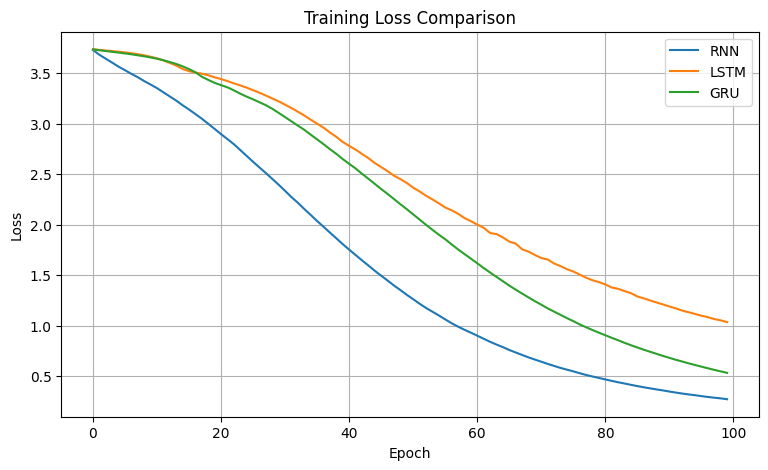

In [28]:
plt.figure(figsize=(9,5))

for network in network_types:
    plt.plot(
        histories[network].history["loss"],
        label=network
    )

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## 7. Text Generation Helper Function

The `generate_sentence` function takes a trained model, a starting seed text, and the number of words to generate. It iteratively predicts the next word based on the current sequence and appends it to the generated sentence.

In [29]:
def generate_sentence(model, seed, words):

    sentence = seed

    for _ in range(words):

        encoded = tokenizer.texts_to_sequences([sentence])[0]

        encoded = pad_sequences(
            [encoded],
            maxlen=max_sequence_length-1,
            padding="pre"
        )

        prediction = model.predict(encoded, verbose=0)

        predicted_index = np.argmax(prediction)

        next_word = index_to_word.get(predicted_index, "")

        sentence += " " + next_word

    return sentence

## 8. Generate Text Examples

Using a common seed text, this section demonstrates the text generation capabilities of each trained model by generating a short sequence of words.

In [30]:
seed_text = "deep learning"

print("\nGenerated Sentences\n")

for network in network_types:

    output = generate_sentence(
        models[network],
        seed_text,
        6
    )

    print(network, ":", output)


Generated Sentences

RNN : deep learning is a powerful branch of artificial
LSTM : deep learning is a powerful branch of artificial
GRU : deep learning is a powerful branch of artificial


## 9. Final Training Accuracy

This section displays the final training accuracy achieved by each model after 100 epochs, providing a quantitative measure of their performance on the training data.

In [31]:
print("\nFinal Training Accuracy")

for network in network_types:

    accuracy = histories[network].history["accuracy"][-1]

    print(f"{network}: {accuracy:.4f}")


Final Training Accuracy
RNN: 0.9773
LSTM: 0.8182
GRU: 0.9773


In [32]:
print("\nFinal Training Accuracy")

for network in network_types:

    accuracy = histories[network].history["accuracy"][-1]

    print(f"{network}: {accuracy:.4f}")


Final Training Accuracy
RNN: 0.9773
LSTM: 0.8182
GRU: 0.9773
